In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.models import resnet18
from torchvision import transforms
from tqdm import tqdm
from torch import nn
from torch.utils.data import Dataset,TensorDataset,DataLoader,random_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from d2l import torch as d2l
import random
import os
import torch.nn.functional as F
from torch.autograd import grad
import torch.nn.init as init
d2l.use_svg_display()

In [2]:
import pandas as pd

def add_column_with_variable_length(df, new_column, column_name, fill_value=None):
    """
    向DataFrame添加长度可能不同的新列，保持总行数只增不减
    
    参数:
        df (pd.DataFrame): 原始DataFrame
        new_column (list/array): 要添加的新列数据
        column_name (str): 新列的名称
        fill_value: 用于填充不足部分的默认值（默认为None）
    
    返回:
        pd.DataFrame: 包含新列的DataFrame
    """
    # 确保输入是DataFrame
    if not isinstance(df, pd.DataFrame):
        raise TypeError("输入df必须是pandas DataFrame")
    
    # 将新列转换为可迭代形式
    new_data = list(new_column)
    
    # 计算新旧长度
    original_length = len(df)
    new_data_length = len(new_data)
    
    # 情况1：新数据比原DataFrame长 - 扩展DataFrame
    if new_data_length > original_length:
        # 创建扩展部分（保持原有列的结构）
        extension = pd.DataFrame(index=range(original_length, new_data_length))
        # 合并扩展部分
        extended_df = pd.concat([df, extension], axis=0)
        # 添加新列
        extended_df[column_name] = new_data
        return extended_df
    
    # 情况2：新数据比原DataFrame短或等长 - 直接添加列
    else:
        # 复制DataFrame避免修改原对象
        result_df = df.copy()
        # 添加新列并用fill_value填充不足部分
        result_df[column_name] = new_data + [fill_value] * (original_length - new_data_length)
        return result_df

['2C_battery-1', '2C_battery-2', '2C_battery-3', '2C_battery-4', '2C_battery-5', '2C_battery-6', '2C_battery-7', '2C_battery-8']


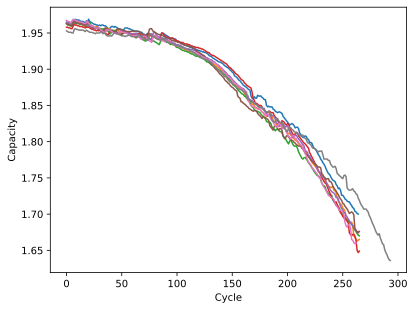

In [5]:
Batch_list=['Batch-1','Batch-2','Batch-3','Batch-4','Batch-5','Batch-6']
def choose_batch(Batch_name):
    Battery_list=[]
    dir='../source_data/XJTU_data/'+Batch_name
    for name in os.listdir(dir):
        Battery_list.append(name.strip('.mat'))
    source_data_path='../source_data/XJTU_data/'+Batch_name+'/'
    target_data_path='../data/XJTU_data/'+Batch_name+'/'+'all/'
    return Battery_list,source_data_path,target_data_path
Battery_list,source_data_path,target_data_path=choose_batch(Batch_list[0])
print(Battery_list)
def smooth_data(sequence, window_size):
    """数据平滑"""
    if window_size < 1:
        raise ValueError("窗口大小必须大于等于1")
    # 初始化平滑后的数据列表
    smoothed_sequence = []
    # 计算窗口内的平均值
    for i in range(len(sequence)):
        # 计算窗口的起始和结束索引
        start_index = max(0, i - window_size + 1)
        end_index = i + 1
        # 计算窗口内的数据平均值
        window_average = sum(sequence[start_index:end_index]) / (end_index - start_index)
        # 将平均值添加到平滑后的数据列表中
        smoothed_sequence.append(window_average)
    return smoothed_sequence
def add_row_index_to_array(arr):
    """
    在输入数组的每一行的第一个元素加上行号，并扩展数组维度。
    
    参数:
    arr (np.ndarray): 形状为 (n, 6) 的输入数组。
    
    返回:
    np.ndarray: 形状为 (n, 7) 的数组。
    """
    # 检查输入数组形状是否为 (n, 6)
    if arr.shape[1] != 10:
        raise ValueError("输入数组必须是形状为 (n, 10) 的数组。")

    # 创建一个新数组，其形状为 (n, 7)，初始化为输入数组
    new_arr = np.zeros((arr.shape[0], 11))
    new_arr[:, 1:] = arr  # 将输入数组的数据复制到新数组的后面六个列
    # 在新数组的每一行的第一个元素加上行号
    new_arr[:, 0] = np.arange(arr.shape[0])
    return new_arr
def make_sequences(text, window_size):
    """用容量作为文本序列text,window是窗口的大小"""
    x, y = [],[]
    for i in range(len(text) - window_size):
        sequence = text[i:i+window_size]
        target = text[i+window_size]

        x.append(sequence)
        y.append(target)
    return np.array(x), np.array(y)
def drop_outlier(array,count,bins):
    """离群值提取--用3sigma方法"""
    index = []
    range_n = np.arange(1,count,bins)
    for i in range_n[:-1]:
        array_lim = array[i:i+bins]
        sigma = np.std(array_lim)
        mean = np.mean(array_lim)
        th_max,th_min = mean + sigma*2, mean - sigma*2
        idx = np.where((array_lim < th_max) & (array_lim > th_min))
        idx = idx[0] + i
        index.extend(list(idx))
    return np.array(index)
def clean_data(array_figs,array_labels):
    index_keep=drop_outlier(array_labels,len(array_labels),35)
    array_figs,array_labels=array_figs[index_keep],array_labels[index_keep]
    array_figs,array_labels=array_figs[drop_outlier(array_labels,len(array_labels),10)],array_labels[drop_outlier(array_labels,len(array_labels),10)]
    return array_figs,array_labels
data_root=target_data_path
df=pd.DataFrame()
for name in Battery_list:
    path=data_root+name+'.npz'
    arrays=np.load(path)
    features,SOHs=clean_data(arrays['array1'],arrays['array2'])
    plt.plot(SOHs)
    df=add_column_with_variable_length(df,SOHs/2,name)
    # """抛弃异常值处理"""
    # index_keep=drop_outlier(SOHs,len(SOHs),35)
    # plt.plot(SOHs[index_keep][drop_outlier(SOHs[index_keep],len(SOHs[index_keep]),10)])
    # plt.plot(process_sequence(SOHs,1))
    plt.xlabel('Cycle')
    plt.ylabel('Capacity')
    # print(features[1][0])
# plt.show()
df.to_csv('../2origin/xjtu_soh.csv')

In [3]:
def setup_seed(seed):
    """set random seed"""
    np.random.seed(seed)  # Numpy module.
    random.seed(seed)  # Python random module.
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed) 
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

def evaluation(y_test, y_predict):
    mse = mean_squared_error(y_test, y_predict)
    rmse = sqrt(mean_squared_error(y_test, y_predict))
    return rmse
def get_data():
    """获取训练集，测试集，验证集"""
    train_list = Battery_list
    train_data=[]
    for b_n in train_list:
        path=data_root+b_n+'.npz'
        arrays = np.load(path)
        a,b=clean_data(arrays['array1'],arrays['array2'])
        a=add_row_index_to_array(a)
        train_data.append([a,b])
    train_features=np.concatenate((train_data[0][0],train_data[1][0],train_data[2][0],train_data[3][0],train_data[4][0]),axis=0)
    train_labls=np.concatenate((train_data[0][1],train_data[1][1],train_data[2][1],train_data[3][1],train_data[4][1]),axis=0)
    train_valid_features=torch.from_numpy(train_features).float()
    train_valid_labels=torch.from_numpy(train_labls).float()
    dataset=TensorDataset(train_valid_features,train_valid_labels)
    # 确定训练集和验证集的大小
    train_size = int(0.6 * len(dataset))  # 80%的训练集
    val_size = len(dataset) - train_size   # 剩余的20%作为验证集
    # 随机分割数据集
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    # 创建DataLoader
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_5_data,test_6_data,test_7_data=[train_data[5][0],train_data[5][1]],[train_data[6][0],train_data[6][1]],[train_data[7][0],train_data[7][1]]
    return train_loader, val_loader, test_5_data,test_6_data,test_7_data

a,b,c,d,e=get_data()
print(d,e)
for x,y in b:
    print(x.shape)

[array([[0.00000000e+00, 8.10116599e-01, 2.05529220e-01, ...,
        7.50713571e-01, 1.00000000e+00, 5.46999916e-03],
       [1.00000000e+00, 8.10116599e-01, 2.05529220e-01, ...,
        7.50713571e-01, 1.00000000e+00, 5.46999916e-03],
       [2.00000000e+00, 8.10116599e-01, 2.05529220e-01, ...,
        7.50713571e-01, 1.00000000e+00, 5.46999916e-03],
       ...,
       [2.60000000e+02, 4.56911290e-01, 8.30281021e-01, ...,
        7.14768346e-01, 1.10282954e-01, 5.22973996e-01],
       [2.61000000e+02, 4.64166178e-01, 7.90670802e-01, ...,
        7.24159078e-01, 1.04209800e-01, 5.26676765e-01],
       [2.62000000e+02, 4.68563913e-01, 7.76807393e-01, ...,
        7.15860345e-01, 9.82746722e-02, 5.29832534e-01]]), array([1.967, 1.966, 1.966, 1.965, 1.964, 1.967, 1.969, 1.968, 1.968,
       1.967, 1.966, 1.966, 1.965, 1.965, 1.965, 1.964, 1.963, 1.963,
       1.964, 1.966, 1.963, 1.962, 1.96 , 1.959, 1.96 , 1.958, 1.957,
       1.957, 1.957, 1.958, 1.956, 1.954, 1.953, 1.952, 1.951, 1.95

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, input_dim=11, output_dim=12, num_heads=4, head_dim=24, dropout=0):
        """用多头注意力进行解码"""
        """
        多头注意力模块。
        :param input_dim: 输入特征维度
        :param output_dim: 输出特征维度
        :param num_heads: 注意力头的数量
        :param head_dim: 每个注意力头的维度
        :param dropout: Dropout 概率
        """
        super(MultiHeadAttention, self).__init__()
        self.input_dim = input_dim-1
        self.output_dim = output_dim-1
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.dropout = dropout
        # 线性变换层，将输入映射到 Q, K, V
        self.query = nn.Linear(input_dim-1, num_heads * head_dim)
        self.key = nn.Linear(input_dim-1, num_heads * head_dim)
        self.value = nn.Linear(input_dim-1, num_heads * head_dim)
        # 输出线性层
        self.fc_out = nn.Linear(num_heads * head_dim, output_dim-1)
        # Dropout 层
        self.dropout_layer = nn.Dropout(dropout)
    def forward(self, x):
        """
        前向传播。
        :param x: 输入张量，形状为 (batch_size, input_dim)
        :return: 输出张量，形状为 (batch_size, output_dim)
        """
        batch_size = x.size(0)
        x_t=x[:,0].unsqueeze(1)
        x=x[:,1:]
        # 线性变换，得到 Q, K, V
        Q = self.query(x).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)  # (batch_size, num_heads, seq_len, head_dim)
        K = self.key(x).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)    # (batch_size, num_heads, seq_len, head_dim)
        V = self.value(x).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)  # (batch_size, num_heads, seq_len, head_dim)
        # 计算注意力分数
        scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(torch.tensor(self.head_dim, dtype=torch.float32))  # (batch_size, num_heads, seq_len, seq_len)
        attention_weights = F.softmax(scores, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        attention_weights = self.dropout_layer(attention_weights)
        # 计算加权和
        attention_output = torch.matmul(attention_weights, V)  # (batch_size, num_heads, seq_len, head_dim)
        # 拼接多头输出
        attention_output = attention_output.transpose(1, 2).contiguous().view(batch_size, -1, self.num_heads * self.head_dim)  # (batch_size, seq_len, num_heads * head_dim)
        # 通过线性层映射到输出维度
        output = self.fc_out(attention_output)  # (batch_size, seq_len, output_dim)
        output=torch.cat((x_t,output.squeeze(1)),dim=-1)
        return output  # (batch_size, output_dim)
"""--------------------------------------------------------多物理场混合专家模型-------------------------------------------------------"""
class MixtureOfExperts(nn.Module):
    def __init__(self, input_dim, num_experts, expert_hidden_dim):
        super(MixtureOfExperts, self).__init__()
        self.num_experts = num_experts
        # 专家网络
        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(input_dim, 2*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(2*expert_hidden_dim, 4*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(4*expert_hidden_dim, 8*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(8*expert_hidden_dim, 16*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(16*expert_hidden_dim, 32*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(32*expert_hidden_dim,64*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(64*expert_hidden_dim,32*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(32*expert_hidden_dim,16*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(16*expert_hidden_dim, 8*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(8*expert_hidden_dim, 4*expert_hidden_dim),
                nn.ReLU(),
                nn.Linear(4*expert_hidden_dim,expert_hidden_dim ),
            )
            for _ in range(num_experts)
        ])
        # 门控网络
        self.gating_network = nn.Linear(input_dim, num_experts)
        # 输出层
        self.output_layer = nn.Linear(expert_hidden_dim, 1)
    def initialize_weights(self):
        nn.init.xavier_uniform_(self.gating_network.weight)
        nn.init.xavier_uniform_(self.output_layer.weight)
    def forward(self, x):
        # 计算所有专家的输出
        expert_outputs = torch.stack([expert(x) for expert in self.experts], dim=1)
        #shape(batch_size,num_expert,expert_hidden_dim)
        # 计算门控网络的输出并应用softmax得到权重
        gate_works=torch.exp(self.gating_network(x)/500)
        gating_outputs = F.softmax(gate_works, dim=1)
        # 将门控网络的输出（权重）与专家网络的输出相乘并求和
        combined_output = torch.sum(expert_outputs * gating_outputs.unsqueeze(-1), dim=1)
        # 通过输出层得到最终输出
        final_output = self.output_layer(combined_output)
        return final_output,expert_outputs      #返回总输出和每个专家输出
    
class PINN_MOE(nn.Module):
    def __init__(self,input_dim=11, output_dim=12, num_heads=4, head_dim=24, dropout=0,expert_input_dim=12, num_experts=3,expert_hidden_dim=2):
        super(PINN_MOE, self).__init__()
        self.Decoupling=MultiHeadAttention(input_dim, output_dim, num_heads, head_dim, dropout)
        self.multi_physics=MixtureOfExperts(expert_input_dim, num_experts,expert_hidden_dim)
        self.physics=nn.Sequential(
            nn.Linear(6, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )
        # self.electricity=nn.Sequential(nn.Linear(expert_hidden_dim, 2*expert_hidden_dim),nn.ReLU(),nn.Linear(2*expert_hidden_dim,expert_hidden_dim),nn.ReLU(),nn.Linear(expert_hidden_dim,2))
        # self.heat=nn.Sequential(nn.Linear(expert_hidden_dim, 2*expert_hidden_dim),nn.ReLU(),nn.Linear(2*expert_hidden_dim,expert_hidden_dim),nn.ReLU(),nn.Linear(expert_hidden_dim,2))
        # self.mechine=nn.Sequential(nn.Linear(expert_hidden_dim, 2*expert_hidden_dim),nn.ReLU(),nn.Linear(2*expert_hidden_dim,expert_hidden_dim),nn.ReLU(),nn.Linear(expert_hidden_dim,2))
        self.parameter_heat=nn.Parameter(torch.tensor(1, dtype=torch.float32))
        self.parameter_electricity1=nn.Parameter(torch.tensor(1, dtype=torch.float32))
        self.parameter_electricity2=nn.Parameter(torch.tensor(1, dtype=torch.float32))
    def  initialize_weights(self):
        nn.init.xavier_uniform_(self.Decoupling.parameters)
        nn.init.xavier_uniform_(self.multi_physics.parameters)
        # nn.init.xavier_uniform_(self.heat.parameters)
        # nn.init.xavier_uniform_(self.mechine.parameters)
        # nn.init.xavier_uniform_(self.electricity.parameters)
        nn.init.xavier_uniform_(self.physics.parameters)
        nn.init.xavier_uniform_(self.parameter_heat)
        nn.init.xavier_uniform_(self.parameter_electricity1)
        nn.init.xavier_uniform_(self.parameter_electricity2)
    def forward(self, tx):
        tx.requires_grad_(True)
        # 解耦输入
        t_x = self.Decoupling(tx)
        def safe_grad(y, x_):
            # 如果 y 本身就不在计算图里（不需要梯度），直接返回 0（但要保持和 x_ 有依赖，方便二阶导）
            if (not torch.is_tensor(y)) or (not y.requires_grad):
                return x_ * 0.0

            g = grad(y, x_, create_graph=True, only_inputs=True, allow_unused=True)[0]
            if g is None:
                # 关键：不能用 zeros_like(x_)，要用 x_*0，让它仍然“挂在”x_上，从而有 grad_fn
                return x_ * 0.0
            return g

        t=t_x[:,0:1]
        x=t_x[:,1:]
        # 预测物理量
        s_pred,experts = self.multi_physics(torch.cat((t,x),dim=1))
        # 计算 s_pred 对 t 和 x 的偏导数
        """综合损失"""
        s_t = grad(s_pred.sum(),t,create_graph=True,only_inputs=True,allow_unused=True)[0]
        s_x = grad(s_pred.sum(),x,create_graph=True,only_inputs=True,allow_unused=True)[0]
        """热效应损失"""
        T_Q = experts[:, 0:1, :].squeeze(1)
        T = T_Q[:, 0:1]
        Q = T_Q[:, 1:2]

        # 选空间坐标（默认用 x 的第 1 维做空间坐标）
        x_phys = x[:, 0:1]

        # 梯度（用 safe_grad 防止 None）
        T_t  = safe_grad(T.sum(), t)
        T_x  = safe_grad(T.sum(), x_phys)
        T_xx = safe_grad(T_x.sum(), x_phys)

        rho_cp = 1.0
        k = self.parameter_heat

        res_heat = rho_cp * T_t - k * T_xx + Q

        loss_heat = torch.mean(res_heat ** 2, dim=1).unsqueeze(1)

        """电化学效应损失"""
        phi_c=experts[:,1:2,:].squeeze(1)
        phi=phi_c[:,0:1]
        c=phi_c[:,1:2]
        phi_t=grad(phi.sum(),t,create_graph=True,only_inputs=True,allow_unused=True)[0]
        phi_x=grad(phi.sum(),x,create_graph=True,only_inputs=True,allow_unused=True)[0]
        c_x=grad(c.sum(),x,create_graph=True,only_inputs=True,allow_unused=True)[0]
        c_t=grad(c.sum(),t,create_graph=True,only_inputs=True,allow_unused=True)[0]
        phi_laplace=grad(phi_x.sum(),x,create_graph=True,only_inputs=True,allow_unused=True)[0]
        c_laplace=grad(c_x.sum(),x,create_graph=True,only_inputs=True,allow_unused=True)[0]
        loss_electricity=torch.mean((c_t -self.parameter_electricity1 * c_laplace -self.parameter_electricity2) ** 2,dim=1).unsqueeze(1)+torch.mean(phi_laplace** 2,dim=1).unsqueeze(1)
        """机械应力损失"""
        sigma_f = experts[:, 2:3, :].squeeze(1)
        sigma = sigma_f[:, 0:1]
        f = sigma_f[:, 1:2]

        # 选空间坐标（默认用 x 的第 1 维做空间坐标）
        x_phys = x[:, 0:1]

        # 1D div(sigma) = dσ/dx
        sigma_x = safe_grad(sigma.sum(), x_phys)

        res_mech = sigma_x + f
        loss_mechine = torch.mean(res_mech ** 2, dim=1).unsqueeze(1)


        # 打印 s_t 和 s_x，确保它们不为 None
        # 计算物理约束 F
        F_input = torch.cat([phi,c,T,Q,sigma,f], dim=1)
        soh = self.physics(F_input)
        # 计算残差 f
        loss_all = 1*loss_electricity+1*loss_heat+1*loss_mechine
        return soh, loss_all,[phi,c,T,Q,sigma,f]


In [5]:
def train(pretrained_model,lr=0.005,epochs=300, weight_decay=1e-4, seed=0, metric='rmse', device='cpu'):
    """function for train"""
    setup_seed(seed)
    print("training seed "+str(seed)+':\n')
    train_loader, val_loader, test_35_data, test_36_data, test_37_data=get_data()
    test_data=[test_35_data, test_36_data, test_37_data]
    model = PINN_MOE()
    model.load_state_dict(torch.load(pretrained_model))
    model=model.to(device)
    for param in model.multi_physics.parameters():
        param.requires_grad = False
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    len_dataloader = len(train_loader)
    test_results=[]
    lists=[]
    train_loss=10
    """早停止获取最佳模型"""
    val_mse=10
    for epoch in range(epochs):
        loss_epoch=0
        for X,y in train_loader:
            X,y = X.to(device), y.to(device)
            y_pred,f,_= model(X)
            f_target = torch.zeros_like(f)
            y_pred = y_pred.squeeze(1)
            loss = criterion(y_pred,y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_epoch += loss
        if (epoch+1)%5==0 and epoch!=0:
            print('Epoch:',epoch+1,'Train_RMSELoss:',loss_epoch/len_dataloader,'\n')
            train_loss=loss_epoch/len_dataloader
        if (epoch+1)%5==0 and epoch!=0:
            val_loss=0
            for val_x,val_y in val_loader:
                val_x,val_y=val_x.to(device),val_y.to(device)
                pre,_,_=model(val_x)
                val_loss+=criterion(pre.squeeze(1),val_y).detach()    
            print('Epoch:',epoch+1,'valid_RMSELoss:',val_loss/len(val_loader),'\n')
            val_mse=val_loss/len(val_loader)
                
        if (val_mse<10e-6 and epoch>30)or (epoch+1)==epochs:
            model=model.cpu()
            for name in test_data:
                X=torch.from_numpy(name[0]).float()
                y=name[1]
                y_pred,_,list=model(X)
                for i in range(len(list)):
                    list[i]=list[i].detach().cpu().numpy()
                lists.append(list)
                y_pred= y_pred.squeeze(0).detach().numpy()
                test_results.append([y,y_pred])
            break
    return test_results,lists

# HUST

In [6]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
pretrained_model='../pretrained/hust_model.pth'
test_results,_=train(pretrained_model,seed=0)
for i in range(3):
    real,pred=test_results[i][0],test_results[i][1]
    rmse=evaluation(real,pred)
    print(rmse)

training seed 0:



C:\Users\pc\AppData\Local\Temp\ipykernel_13492\3217803037.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(pretrained_model))


Epoch: 5 Train_RMSELoss: tensor(0.0019, grad_fn=<DivBackward0>) 

Epoch: 5 valid_RMSELoss: tensor(0.0016) 

Epoch: 10 Train_RMSELoss: tensor(0.0008, grad_fn=<DivBackward0>) 

Epoch: 10 valid_RMSELoss: tensor(0.0008) 

Epoch: 15 Train_RMSELoss: tensor(0.0004, grad_fn=<DivBackward0>) 

Epoch: 15 valid_RMSELoss: tensor(0.0005) 

Epoch: 20 Train_RMSELoss: tensor(0.0002, grad_fn=<DivBackward0>) 

Epoch: 20 valid_RMSELoss: tensor(0.0003) 

Epoch: 25 Train_RMSELoss: tensor(0.0002, grad_fn=<DivBackward0>) 

Epoch: 25 valid_RMSELoss: tensor(0.0002) 

Epoch: 30 Train_RMSELoss: tensor(0.0001, grad_fn=<DivBackward0>) 

Epoch: 30 valid_RMSELoss: tensor(0.0002) 

Epoch: 35 Train_RMSELoss: tensor(9.1341e-05, grad_fn=<DivBackward0>) 

Epoch: 35 valid_RMSELoss: tensor(8.8247e-05) 

Epoch: 40 Train_RMSELoss: tensor(7.4581e-05, grad_fn=<DivBackward0>) 

Epoch: 40 valid_RMSELoss: tensor(7.9972e-05) 

Epoch: 45 Train_RMSELoss: tensor(9.6100e-05, grad_fn=<DivBackward0>) 

Epoch: 45 valid_RMSELoss: tensor(8.

# CACLE

In [7]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
pretrained_model='../pretrained/cacle_model.pth'
test_results,_=train(pretrained_model,seed=0)
for i in range(3):
    real,pred=test_results[i][0],test_results[i][1]
    rmse=evaluation(real,pred)
    print(rmse)

training seed 0:



C:\Users\pc\AppData\Local\Temp\ipykernel_13492\3217803037.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(pretrained_model))


Epoch: 5 Train_RMSELoss: tensor(0.0081, grad_fn=<DivBackward0>) 

Epoch: 5 valid_RMSELoss: tensor(0.0089) 

Epoch: 10 Train_RMSELoss: tensor(0.0028, grad_fn=<DivBackward0>) 

Epoch: 10 valid_RMSELoss: tensor(0.0023) 

Epoch: 15 Train_RMSELoss: tensor(0.0006, grad_fn=<DivBackward0>) 

Epoch: 15 valid_RMSELoss: tensor(0.0006) 

Epoch: 20 Train_RMSELoss: tensor(0.0007, grad_fn=<DivBackward0>) 

Epoch: 20 valid_RMSELoss: tensor(0.0006) 

Epoch: 25 Train_RMSELoss: tensor(0.0006, grad_fn=<DivBackward0>) 

Epoch: 25 valid_RMSELoss: tensor(0.0006) 

Epoch: 30 Train_RMSELoss: tensor(0.0006, grad_fn=<DivBackward0>) 

Epoch: 30 valid_RMSELoss: tensor(0.0008) 

Epoch: 35 Train_RMSELoss: tensor(0.0006, grad_fn=<DivBackward0>) 

Epoch: 35 valid_RMSELoss: tensor(0.0006) 

Epoch: 40 Train_RMSELoss: tensor(0.0008, grad_fn=<DivBackward0>) 

Epoch: 40 valid_RMSELoss: tensor(0.0008) 

Epoch: 45 Train_RMSELoss: tensor(0.0006, grad_fn=<DivBackward0>) 

Epoch: 45 valid_RMSELoss: tensor(0.0006) 

Epoch: 50 Tr